In [1]:
from importlib.metadata import version
print("langchain version: ", version("langchain"))
print("langgraph version: ", version("langgraph"))
print("langchain-openai version: ", version("langchain-openai"))
print("langchain-core version: ", version("langchain-core"))
print("langchain_community version: ", version("langchain_community"))
print("langchain_mcp_adapters version: ", version("langchain_mcp_adapters"))
print("tavily-python version: ", version("tavily-python"))

langchain version:  1.3.11
langgraph version:  1.2.6
langchain-openai version:  1.3.3
langchain-core version:  1.4.8
langchain_community version:  0.4.2
langchain_mcp_adapters version:  0.3.0
tavily-python version:  0.7.26


In [2]:
import os
from dotenv import load_dotenv
import openai
load_dotenv()

True

2026-07-05 23:55:44 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'draft' with handle 'gpt-5.4-nano' (timeout=600)
2026-07-05 23:55:45 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_summarizer' with handle 'gpt-5.4-nano' (timeout=600)
2026-07-05 23:55:45 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'gpt-5.4-nano' (timeout=600)
2026-07-05 23:55:45 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_main' with handle 'gpt-5.4-nano' (timeout=600)
2026-07-05 23:55:45 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_compressor' with handle 'gpt-5.4-nano' (timeout=600)
2026-07-05 23:55:45 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'red_team' with handle 'gpt-5.4-mini' (timeout=600)
2026-07-05 23:55:45 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'evaluator' with handle

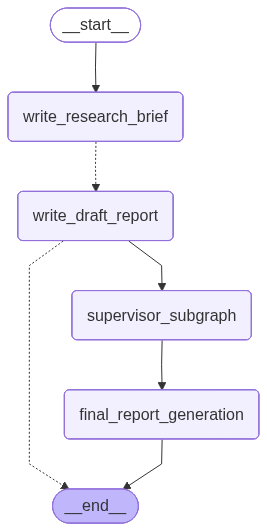

In [3]:
from IPython.display import Image, display
from deep_research.agent_builder import deep_researcher_builder
from langgraph.checkpoint.memory import InMemorySaver
import warnings

warnings.filterwarnings("ignore")
checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({
    "messages":[
        HumanMessage(content="我是金融学研究者，想了解 ESG 表现对企业融资成本的影响。请帮我写一份简短调研报告，分析主要理论机制、实证结论、争议问题，以及哪些方向更值得继续研究。")
        ]
        },config=thread)

2026-07-05 23:58:00 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=0, messages=2)
2026-07-05 23:58:03 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-07-05 23:58:03 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-07-05 23:58:03 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=1, messages=4)
2026-07-05 23:58:06 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=3
2026-07-05 23:58:06 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=0 conduct=3 refine=0
2026-07-05 23:58:07 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=1
2026-07-05 23:58:07 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-07-05 23:58:07 [INFO] 

In [ ]:
from rich.console import Console
from rich.markdown import Markdown

# 创建控制台对象
console = Console()
# console.print(Markdown(result["final_report"]))

Agent 个性化“个性化记忆（Memory）”模块：工程落地调研报告（面向 MVP 与未来演进）                  

1. 背景：Memory 在 Agent 中解决的核心问题                                                                          

在 Agent                                                                                                           
产品中，“个性化记忆”通常同时覆盖三类诉求：第一是会话连续性（用户近期讨论的目标、约束、确认事项在后续轮次仍应被保留 
），第二是跨会话个性化（偏好、背景、长期目标/习惯等沉淀成可复用知识），第三是可控与抗污染（避免把错误/临时信息写入 
长期记忆，并提供撤回、删除、审计等治理能力）。工程落地时，Memory                                                   
往往不只是“把文本存起来”，而是一个贯穿表征—写入—检索—注入—更新/覆盖—治理审计—合规安全的系统。                      

从当前主流实现的证据可以看到，一个可行的产品与工程抽象是：把 Memory                                                
拆成短期记忆与长期记忆两条链路，它们在“数据保真度、成本结构、可控性与遗忘机制”上有明显差异。短期更偏向低延迟的上下 
文承载与可预算的最近记忆；长期更偏向按需读取的外部记忆/块化画像与写入门控 + 去重合并 + 删除/撤回/版本化治理。      

-------------------------------------------------------------------------------------------------------------------

2. 短期记忆与长期记忆：技术路线、产品形态与工程取舍                                                                

下文按简报要求，从技术路线、数据结构与更新策略、延迟/成本/可控性/遗忘取舍，以及长期写入触发、合并去重衰减与防污染（
memory poisoning）等维度系统梳理。                                                                                 

2.1 短期记忆（Short-term Memory）                                                                                  

2.1.1 会话窗口注入（Buffer / Context stuffing）：最简单但随 token 线性增长                                         

产品形态是“同一会话内连续对话”。典型实现是把历史消息作为“buffer”直接拼接到 prompt 中。LangChain 的                 
ConversationBufferMemory                                                                                           
属于这一路线：它“存储整个对话历史”，并提示当历史过长可能需要额外处理以适配模型上下文窗口。[1][2]                   

在数据结构上，ConversationBufferMemory 内部是一个 buffer（字符串或消息对象），并通过 save_context                  
写入输入输出对（inputs/outputs）到内部历史；随后使用 load_memory_variables                                         
将历史转换为模型可用变量对进行注入。[1][2] 读取时可以配置 return_messages=True 以返回 HumanMessage/AIMessage       
对象形态。[2]                                                                                                      

工程取舍上，它的主要成本来自注入 token                                                                             
与推理开销的线性增长；可控性体现在“遗忘主要由上下文截断自然发生”，因此遗忘机制的可预测性较强，但准确性与体验在长对 
话上会退化（需要摘要或外部检索兜底）。该路线缺少结构化治理能力（如撤回/审计），因此通常作为“短期兜底层”。          

2.1.2 会话级结构化状态缓存（Session state）：低成本、可验证，但需要状态建模                                        

在工程落地中，很多团队会把“近期关键事实”从纯文本历史中抽取为结构化状态（例如阶段、偏好、已确认实体、待办列表、工具 
调用结果的摘要），让规划/执行直接读取结构化字段而非长历史。虽然简报要求的主证据集中在                              
LangChain/LlamaIndex/Letta/Mem0/Haystack，但从系统抽象上它通常与“短期 FIFO 队列 + token 配额 /                     
摘要更新”共同构成短期层。其优点是延迟低且更容易做字段级验证和回滚；缺点是需要设计并维护                            
schema、以及把“文本到状态”的抽取质量做扎实。                                                                       

在本次可追溯证据中，LlamaIndex                                                                                     
给出的短期机制在实现层面更“落地可验证”（见下一节），因此结构化状态缓存更适合作为产品特性补充，而不是本报告的主要技 
术证据链。                                                                                                         

2.1.3 滑动摘要/会话总结（ConversationSummary）：用“每轮摘要更新”替代长上下文                                       

摘要记忆路线通过持续压缩对话历史来控制 token 成本。LangChain 的 ConversationSummaryMemory                          
明确给出：它会“持续总结对话历史”，并且“每次会话轮次后更新摘要”，摘要可用于为模型提供上下文。[3][4]                 

典型数据结构是一个 summary 字符串（或少量结构化字段），更新策略是“每轮写一次”。ConversationSummaryMemory           
的产品形态是“长对话依然能保持基本连续性，但细节逐步被压缩”。因此它的遗忘机制是“压缩式遗忘”：细节被摘要覆盖后无法再 
被逐字检索到（除非另有检索/外部长期记忆兜底）。此外它通常带来额外 LLM                                              
调用成本（每轮多一次摘要更新或在摘要模块中使用独立链路），但从整体 token                                           
预算看往往更划算，尤其是上下文膨胀成为瓶颈时。                                                                     

2.1.4 短期向量索引（Recent retrieval via vector store）：以“相似片段注入”替代“按时间拼接”                          

将会话片段写入向量库并按输入相似度检索，是另一条常见短期路线。LangChain 的 VectorStoreRetrieverMemory              
明确描述：把对话历史存入向量存储，并“基于输入检索与过去相关的部分”。[5]                                            

该路线的产品形态更接近“会话内检索增强”，而不是纯序列上下文。其数据结构是向量库条目（通常包含片段

In [5]:
from datetime import date

path = f'./eco_output_report_{date.today().strftime("%Y-%m-%d")}.md'

with open(path, "w", encoding="utf-8") as fd:
    fd.write(result["final_report"])

print(f"调研报告已保存在 {path}.")

调研报告已保存在 ./eco_output_report_2026-07-06.md.


In [7]:
print(result["final_report"])

# Agent 个性化“个性化记忆（Memory）”模块：工程落地调研报告（面向 MVP 与未来演进）

## 1. 背景：Memory 在 Agent 中解决的核心问题

在 Agent 产品中，“个性化记忆”通常同时覆盖三类诉求：第一是会话连续性（用户近期讨论的目标、约束、确认事项在后续轮次仍应被保留），第二是跨会话个性化（偏好、背景、长期目标/习惯等沉淀成可复用知识），第三是可控与抗污染（避免把错误/临时信息写入长期记忆，并提供撤回、删除、审计等治理能力）。工程落地时，Memory 往往不只是“把文本存起来”，而是一个贯穿**表征—写入—检索—注入—更新/覆盖—治理审计—合规安全**的系统。

从当前主流实现的证据可以看到，一个可行的产品与工程抽象是：把 Memory 拆成**短期记忆**与**长期记忆**两条链路，它们在“数据保真度、成本结构、可控性与遗忘机制”上有明显差异。短期更偏向**低延迟的上下文承载**与**可预算的最近记忆**；长期更偏向**按需读取的外部记忆/块化画像**与**写入门控 + 去重合并 + 删除/撤回/版本化治理**。

---

## 2. 短期记忆与长期记忆：技术路线、产品形态与工程取舍

下文按简报要求，从技术路线、数据结构与更新策略、延迟/成本/可控性/遗忘取舍，以及长期写入触发、合并去重衰减与防污染（memory poisoning）等维度系统梳理。

## 2.1 短期记忆（Short-term Memory）

### 2.1.1 会话窗口注入（Buffer / Context stuffing）：最简单但随 token 线性增长
**产品形态**是“同一会话内连续对话”。典型实现是把历史消息作为“buffer”直接拼接到 prompt 中。LangChain 的 `ConversationBufferMemory` 属于这一路线：它“存储整个对话历史”，并提示当历史过长可能需要额外处理以适配模型上下文窗口。[1][2]

在数据结构上，`ConversationBufferMemory` 内部是一个 buffer（字符串或消息对象），并通过 `save_context` 写入输入输出对（inputs/outputs）到内部历史；随后使用 `load_memory_variables` 将历史转换为模型可用变量对进行注